========== FIRST 5 ROWS ==========
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

========== DATASET SHAPE ==========
(398, 9)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------    

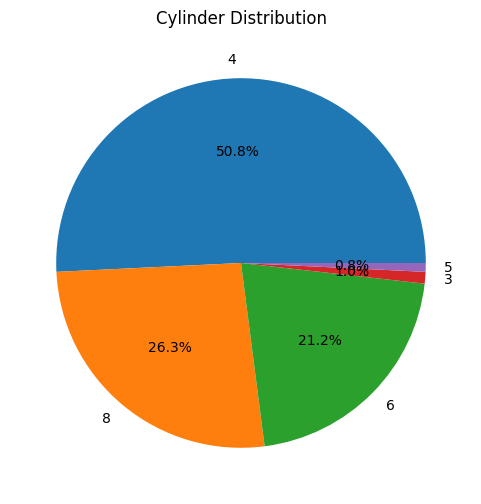

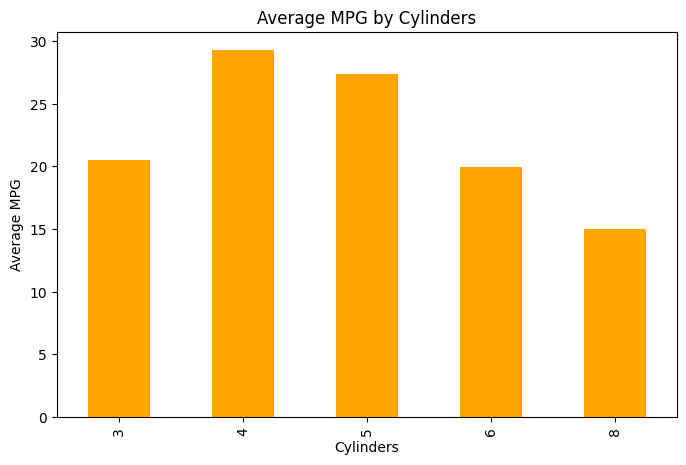

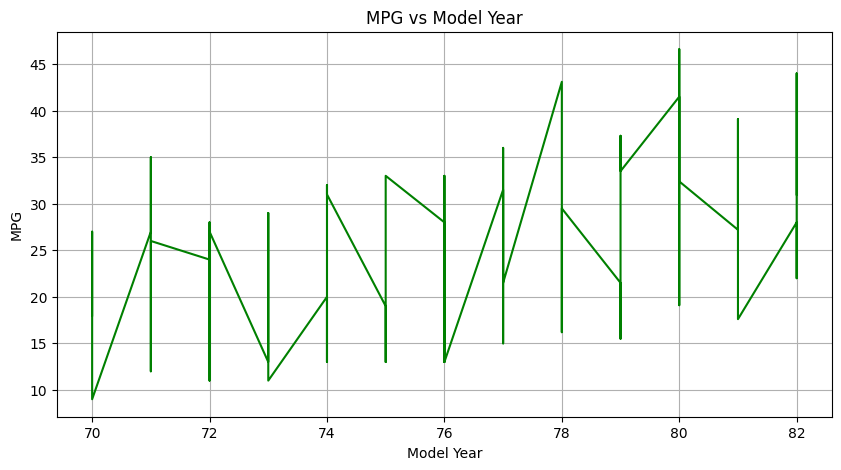


Training Shape: (313, 1)
Testing Shape : (79, 1)

========== TRAINING DETAILS ==========
Intercept: 40.606097600118346
Coefficient: -0.16259724322918453

Regression Equation
MPG = 40.6061 + (-0.1626 * Horsepower)

========== TRAINING RESULTS ==========
     Metric  Training Value
0       MAE        3.847347
1       MSE       24.475168
2      RMSE        4.947238
3  R2 Score        0.612119

========== TESTING RESULTS ==========
     Metric  Testing Value
0       MAE       3.782513
1       MSE      22.153237
2      RMSE       4.706723
3  R2 Score       0.565968

========== ACTUAL VS PREDICTED ==========
   Actual MPG  Predicted MPG
0        26.0          29.39
1        21.6          21.91
2        36.1          30.85
3        26.0          29.22
4        27.0          26.62
5        28.0          28.41
6        13.0          12.96
7        26.0          28.41
8        19.0          25.16
9        29.0          32.64


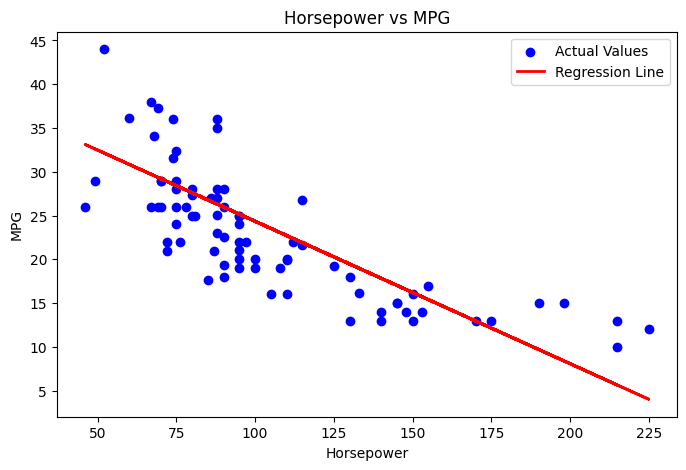


========== FINAL SUMMARY ==========
    Dataset       MAE        MSE      RMSE  R2 Score
0  Training  3.847347  24.475168  4.947238  0.612119
1   Testing  3.782513  22.153237  4.706723  0.565968

PROJECT EXECUTED SUCCESSFULLY


In [1]:
# ==========================================
# SIMPLE LINEAR REGRESSION PROJECT
# ERROR-FREE VERSION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. LOAD DATASET
# ==========================================

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

print("========== FIRST 5 ROWS ==========")
print(df.head())

# ==========================================
# 2. DATASET STRUCTURE
# ==========================================

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# ==========================================
# 3. PREPROCESSING
# ==========================================

df.dropna(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)

# ==========================================
# 4. PIE CHART
# ==========================================

plt.figure(figsize=(6,6))

cylinder_counts = df['cylinders'].value_counts()

plt.pie(
    cylinder_counts,
    labels=cylinder_counts.index,
    autopct='%1.1f%%'
)

plt.title("Cylinder Distribution")
plt.show()

# ==========================================
# 5. BAR CHART
# ==========================================

plt.figure(figsize=(8,5))

avg_mpg = df.groupby('cylinders')['mpg'].mean()

avg_mpg.plot(
    kind='bar',
    color='orange'
)

plt.title("Average MPG by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average MPG")
plt.show()

# ==========================================
# 6. LINE CHART
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    df['model_year'],
    df['mpg'],
    color='green'
)

plt.title("MPG vs Model Year")
plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.grid(True)

plt.show()

# ==========================================
# 7. FEATURE SELECTION
# ==========================================

# Simple Linear Regression requires ONE input feature

X = df[['horsepower']]
y = df['mpg']

# ==========================================
# 8. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# ==========================================
# 9. TRAIN MODEL
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

# ==========================================
# 10. TRAINING DETAILS
# ==========================================

print("\n========== TRAINING DETAILS ==========")

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

print("\nRegression Equation")

print(
    f"MPG = {model.intercept_:.4f} + "
    f"({model.coef_[0]:.4f} * Horsepower)"
)

# ==========================================
# 11. TRAINING PREDICTIONS
# ==========================================

train_pred = model.predict(X_train)

# ==========================================
# 12. TRAINING EVALUATION
# ==========================================

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

# ==========================================
# 13. TESTING PREDICTIONS
# ==========================================

test_pred = model.predict(X_test)

# ==========================================
# 14. TESTING EVALUATION
# ==========================================

test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_pred)

# ==========================================
# 15. TRAINING RESULTS TABLE
# ==========================================

training_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Training Value": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ]
})

print("\n========== TRAINING RESULTS ==========")
print(training_results)

# ==========================================
# 16. TESTING RESULTS TABLE
# ==========================================

testing_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Testing Value": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

print("\n========== TESTING RESULTS ==========")
print(testing_results)

# ==========================================
# 17. ACTUAL VS PREDICTED TABLE
# ==========================================

comparison = pd.DataFrame({
    "Actual MPG": y_test.values,
    "Predicted MPG": np.round(test_pred, 2)
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison.head(10))

# ==========================================
# 18. REGRESSION GRAPH
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(
    X_test,
    y_test,
    color='blue',
    label='Actual Values'
)

plt.plot(
    X_test,
    test_pred,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()

plt.show()

# ==========================================
# 19. FINAL SUMMARY TABLE
# ==========================================

summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, test_mae],
    "MSE": [train_mse, test_mse],
    "RMSE": [train_rmse, test_rmse],
    "R2 Score": [train_r2, test_r2]
})

print("\n========== FINAL SUMMARY ==========")
print(summary)

print("\nPROJECT EXECUTED SUCCESSFULLY")